# Лабораторная работа 1. Осциллограммы.

* Наиболее распространенной формой представления цифровых сигналов в звуковых редакторах является **осциллограмма**.

*  **Осциллограмма** – это представление цифрового сигнала в координатах Амплитуда × Время.

* Эффекты дискретизации и квантования находят свое проявление в осциллограмме.

 <hr>    

<font style="color:#1560BD;" size="5">[Начальные установки](#introduction)</font>

<font style="color:#1560BD;" size="5">[Задание 1](#job1)</font>    

<font style="color:#1560BD;" size="5">[Задание 2](#job2)</font>    

<font style="color:#1560BD;" size="5">[Задание 3](#job3)</font>    

<font style="color:#1560BD;" size="5">[Задание 4](#job4)</font>        

<font style="color:#1560BD;" size="5">[Задание 5](#job5)</font>

## Начальные установки
<a id="introduction"></a>

In [ ]:
# Импорт библиотек
import matplotlib.pyplot as plt
import numpy as np
import librosa

# Игнорируем предупреждения
from warnings import filterwarnings

filterwarnings("ignore")

In [ ]:
# Проверка версии библиотеки
print(librosa.__version__)

0.11.0


In [ ]:
# Конфигурируем директорию данных
Speech_dir = "Speech/LabWork1"  # Речевые треки для лабораторной работы

# Используемые частоты дискретизации
sr8000 = 8000
sr16000 = 16000

<div class="alert alert-block alert-info">

## Задание 1
<a id="job1"></a>
* Возьмите стерео сигнал **ST_rms1000.wav** (белый шум СКО 1000).

* Разделите стерео сигнал на два сигнала моно.

* Поделите один из сигналов на $1000$, а затем умножьте на $1000$.

* Сравните осциллограммы сигналов и объясните результат.
</div>

In [ ]:
# Преобразование float (-1,1) - int16 (-32767, 32767)
def soundDataToInt(Signal):
    return np.array([int(s * 32768) for s in Signal]).astype(np.int16)


# Преобразование int16 (-32767, 32767) - float (-1,1)
def soundDataToFloat(Signal):
    return np.array([np.float32((s >> 2) / (32768.0)) for s in Signal])

In [ ]:
# Загружаем сигнал ST_rms1000.wav (в стерео режиме, с исходной частотой)
# Сигнал загружается в формате float, в диапазоне (-1,1)
data_ST_rms1000, sr_ST_rms1000 = librosa.load(
    "/home/artyom/myprojects/ITMO/AEA/mors/speech/ST_rms1000.wav", sr=None, mono=False
)

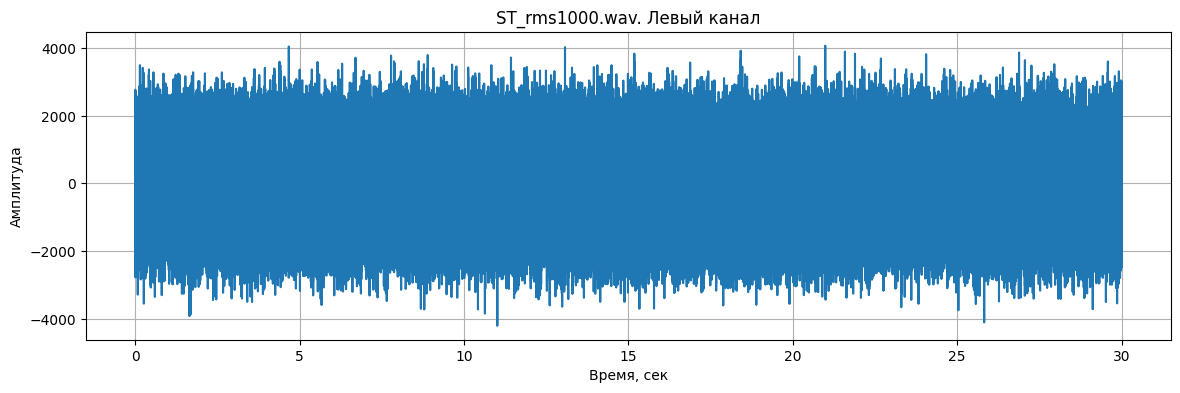

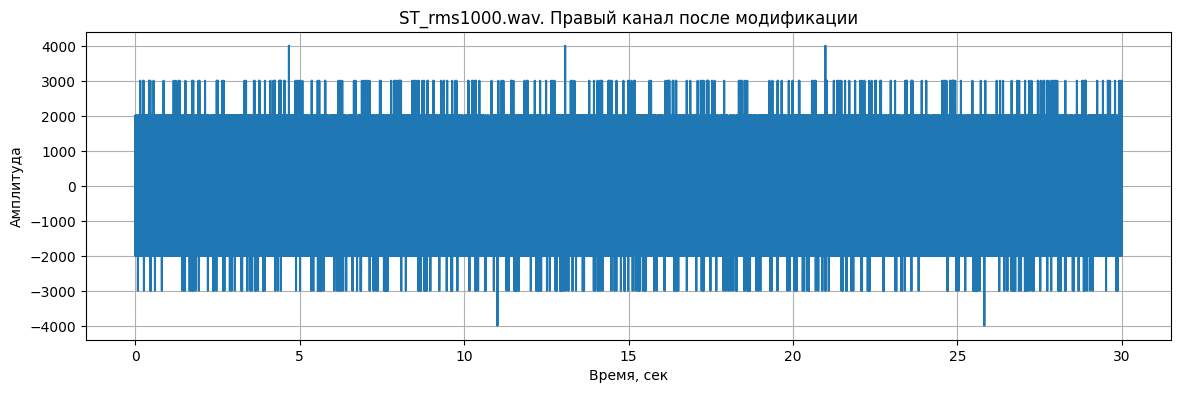

In [ ]:
# Осцилограммы каналов
# Переводим оба канала в формат int16
data_ST_rms1000_int_0 = soundDataToInt(data_ST_rms1000[0])
data_ST_rms1000_int_1 = soundDataToInt(data_ST_rms1000[1])

# Делим и умножам правый канал на 1000 (как int16)
data_ST_rms1000_int_1 = np.true_divide(data_ST_rms1000_int_1, 1000).astype(np.int16)
data_ST_rms1000_int_1 = data_ST_rms1000_int_1 * 1000

time = np.linspace(
    0, len(data_ST_rms1000[0]) / sr_ST_rms1000, num=len(data_ST_rms1000[0])
)

# Осцилограмма левого канала
plt.figure(figsize=(14, 4))
plt.title("ST_rms1000.wav. Левый канал")
plt.plot(time, data_ST_rms1000_int_0)
plt.grid(True)
plt.xlabel("Время, сек")
plt.ylabel("Амплитуда")
plt.show()

# Осцилограмма правого канала
plt.figure(figsize=(14, 4))
plt.title("ST_rms1000.wav. Правый канал после модификации")
plt.plot(time, data_ST_rms1000_int_1)
plt.xlabel("Время, сек")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 1:</b>
<a id="answer-job1"></a>
Из-за квантования сигнала (перевода в int16) мы после деления на 1000 потеряли десятичные части (2500 -> 2.5 -> 2 -> 2000), после чего наш сигнал стал меньшего разрешения
</div>

<div class="alert alert-block alert-info">

## Задание 2
<a id="job2"></a>

* Возьмите сигнал **rms1000.wav**. Вычислите среднеквадратичное отклонение (с окном $20$ мс) и постройте график. 

* Увеличьте и уменьшите амплитуду сигнала вдвое. Как зависит оценка среднеквадратичного отклонения от амплитуды сигнала?

* Добавьте к исходному сигналу константы $0.10, 0.05$, вычислите среднеквадратичное отклонение и постройте графики полученных сигналов в том же окне. 

* Объясните полученные результаты. 
</div>

In [ ]:
# Вычисление rms
def rms(x, block_size, hop_size):
    return np.array(
        [x[i : i + block_size].std() for i in range(0, len(x) - block_size, hop_size)]
    )

In [ ]:
# Загружаем сигнал rms1000.wav (с исходной частотой)
data_rms1000, sr_rms1000 = librosa.load(
    "/home/artyom/myprojects/ITMO/AEA/mors/speech/rms1000.wav", sr=None
)

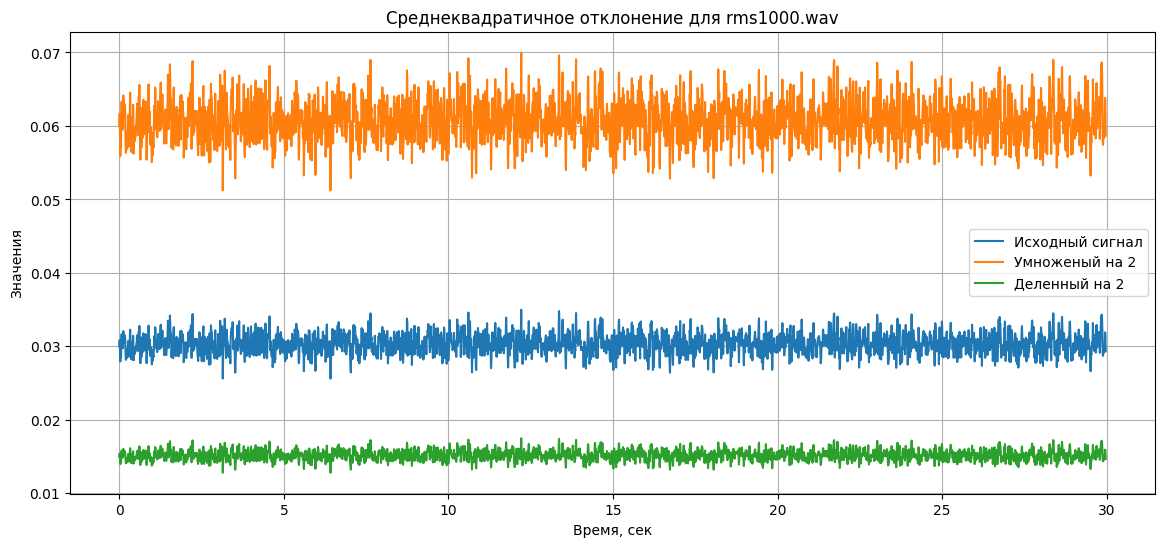

In [ ]:
# Вычисляем RMS (с окном 20 мс, перекрытие 50%) и строим график
block_size = round(sr_rms1000 / 50)
hop_size = round(block_size / 2)

rms1000_rms = rms(data_rms1000, block_size, hop_size)
frames = range(len(rms1000_rms))
t = librosa.frames_to_time(frames, hop_length=hop_size, sr=sr_rms1000)

# Умножаем на 2
data_rms1000_2 = data_rms1000 * 2
rms1000_rms_2 = rms(data_rms1000_2, block_size, hop_size)

# Делим на 2
data_rms1000_05 = data_rms1000 * 0.5
rms1000_rms_05 = rms(data_rms1000_05, block_size, hop_size)

# График энергии
plt.figure(figsize=(14, 6))
plt.title("Среднеквадратичное отклонение для rms1000.wav")
plt.grid(True)
plt.xlabel("Время, сек")
plt.ylabel("Значения")
plt.plot(t, rms1000_rms, label="Исходный сигнал")
plt.plot(t, rms1000_rms_2, label="Умноженый на 2")
plt.plot(t, rms1000_rms_05, label="Деленный на 2")
plt.legend()
plt.show()

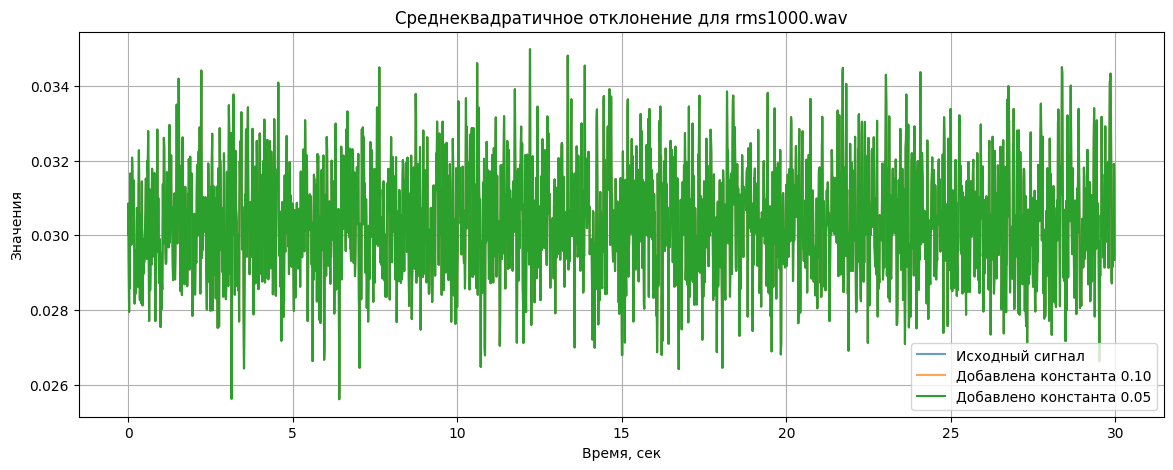

In [ ]:
# Добавляем к сигналу константы, вычисляем среднеквадратичное отклонение (с окном 20 мс, перекрытие 50%) и строим график
data_rms1000_const1 = data_rms1000 + 0.10
data_rms1000_const2 = data_rms1000 + 0.05

rms1000_const1_rms = rms(data_rms1000_const1, block_size, hop_size)
rms1000_const2_rms = rms(data_rms1000_const2, block_size, hop_size)

# График энергии
plt.figure(figsize=(14, 5))
plt.title("Cреднеквадратичное отклонение для rms1000.wav")
plt.grid(True)
plt.xlabel("Время, сек")
plt.ylabel("Значения")
plt.plot(t, rms1000_rms, label="Исходный сигнал", alpha=0.7)
plt.plot(t, rms1000_const1_rms, label="Добавлена константа 0.10", alpha=0.7)
plt.plot(t, rms1000_const2_rms, label="Добавлено константа 0.05")
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 2:</b>
<a id="answer-job2"></a>

1) Исходя из формулы СКО, если умножить сигнал на число, то и значение СКО изменится линейно этому коэффициенту, так что при изменение амплитуды сигнала, значение СКО изменяется пропорционально.

2) При добавление константы ко всему сигналу, мы на равные значения увеличиваем все числа, а значит значение СКО не изменится.

</div>

<div class="alert alert-block alert-info">

## Задание 3
<a id="job3"></a>
* Возьмите сигнал **16kHz_rms2000.wav** (белый шум $16$ кГц).

* Вычислите среднеквадратичное отклонение, постройте график.

* Передискретизируйте сигнал на $8$ кГц, вычислите среднеквадратичное отклонение, постройте график полученных сигналов в том же окне.

* Передискретизируйте сигнал обратно с $8$ кГц на $16$ кГц, вычислите среднеквадратичное отклонение, постройте график полученных сигналов в том же окне.

* Как изменилось среднеквадратичное отклонение сигнала?    

* Объясните полученные результаты.
</div>

In [ ]:
# Загружаем сигнал 16kHz_rms2000.wav (с исходной частотой)
data_rms2000_16kHz, sr_rms2000_16kHz = librosa.load(
    "/home/artyom/myprojects/ITMO/AEA/mors/speech/16kHz_rms2000.wav", sr=None
)

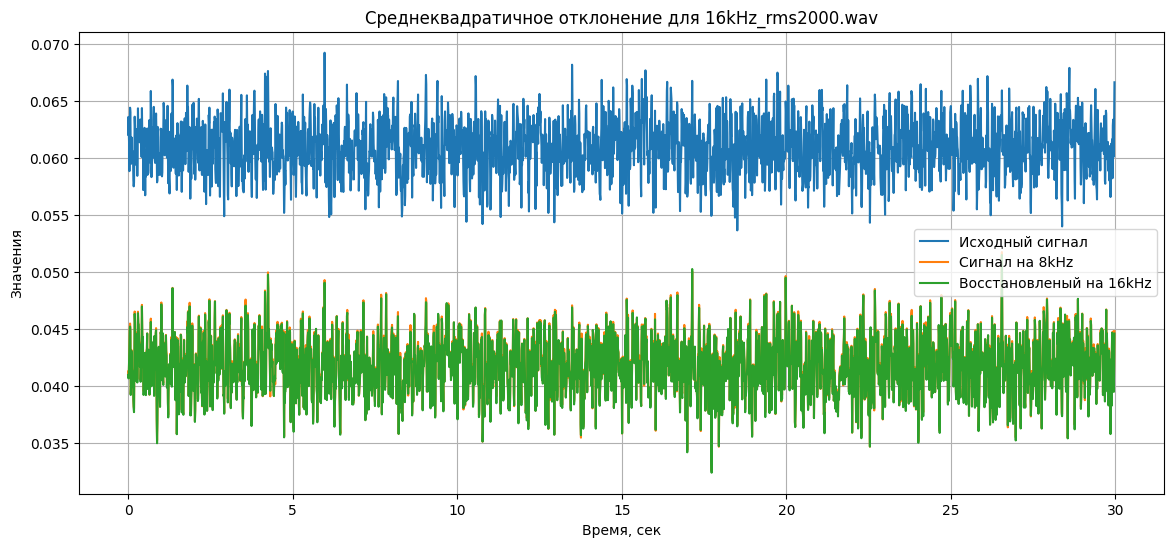

In [ ]:
# Вычисляем среднеквадратичное отклонение исходного сигнала (с окном 20 мс, перекрытие 50%) и строим график
block_size = round(sr_rms2000_16kHz / 50)
hop_size = round(block_size / 2)

rms2000_16kHz_rms = rms(data_rms2000_16kHz, block_size, hop_size)
frames = range(len(rms2000_16kHz_rms))
t = librosa.frames_to_time(frames, hop_length=hop_size, sr=sr_rms2000_16kHz)

# Передискретизируем сигнал на 8кГц и вычисляем среднеквадратичное отклонение
data_rms2000_8kHz = librosa.resample(
    data_rms2000_16kHz, orig_sr=sr_rms2000_16kHz, target_sr=sr8000
)

block_size2 = round(sr8000 / 50)
hop_size2 = round(block_size2 / 2)

rms2000_8kHz_rms = rms(data_rms2000_8kHz, block_size2, hop_size2)
frames = range(len(rms2000_8kHz_rms))
t2 = librosa.frames_to_time(frames, hop_length=hop_size2, sr=sr8000)

# Передискретизируем сигнал из 8кГц в 16кГц и вычисляем среднеквадратичное отклонение
data_rms2000_16kHz_R = librosa.resample(
    data_rms2000_8kHz, orig_sr=sr8000, target_sr=sr16000
)
rms2000_16kHz_R_rms = rms(data_rms2000_16kHz_R, block_size, hop_size)

# График RMS
plt.figure(figsize=(14, 6))
plt.title("Среднеквадратичное отклонение для 16kHz_rms2000.wav")
plt.grid(True)
plt.xlabel("Время, сек")
plt.ylabel("Значения")
plt.plot(t, rms2000_16kHz_rms, label="Исходный сигнал")
plt.plot(t2, rms2000_8kHz_rms, label="Сигнал на 8kHz")
plt.plot(t, rms2000_16kHz_R_rms, label="Восcтановленый на 16kHz")
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 3:</b>
<a id="answer-job3"></a>

После даунсемплинга сигнала мы оберзали половину энергии сигнала (поскольку в белом шуме все частоты в равной пропорции), из-за чего значение RMS уменьшилось на корень изменения энергии.

Что касается восстановленного сигнала, в идеале после вставки нулей и применения фильтра энергия сигнала должна была приблизиться к изначальной. На рисунке она на уровне 8 кГц, так что может быть фильтрация не была применена, были просто добавлены нули в сигнал, из-за чего энергия осталась как после даунсемплинга.
</div>

<div class="alert alert-block alert-info">

## Задание 4
<a id="job4"></a>
* Сгенерируйте синус с частотой $3,9$ кГц с частотами дискретизации $8$ кГц и $16$ кГц

* Постройте в одном окне осциллограммы.

* Чем различаются осциллограммы сигнала при разных частотах дискретизации?
</div>

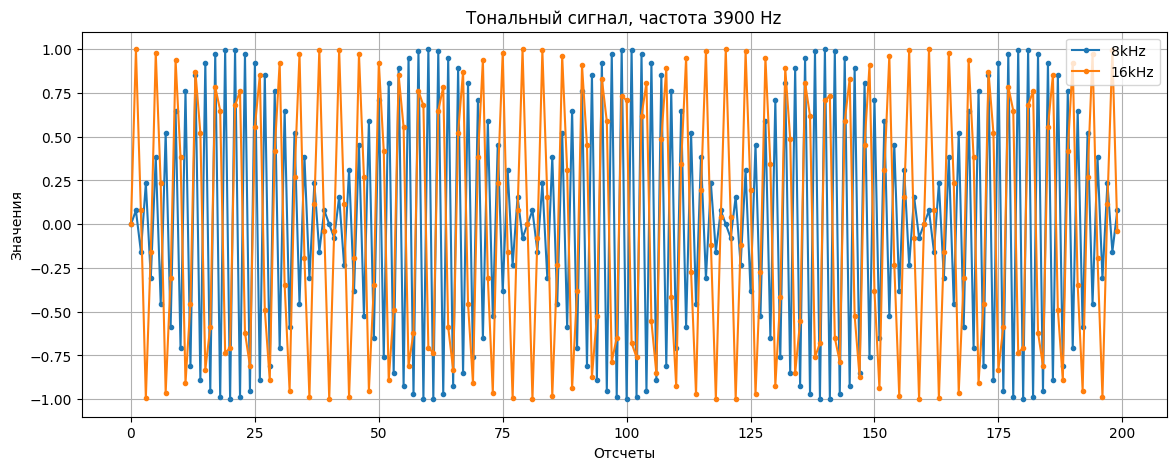

In [ ]:
# Генерация тональных сигналов: основная частота, длительность(сек.), частота дискретизации (гц)
sample_rate = 3900
tone8kHz = librosa.tone(sample_rate, duration=1, sr=sr8000)
tone16kHz = librosa.tone(sample_rate, duration=1, sr=sr16000)

# Строим осциллограммы (берем первые 200 точек)
nSamples = 200
plt.figure(figsize=(14, 5))
plt.title("Тональный сигнал, частота 3900 Hz")
plt.plot(tone8kHz[0:nSamples], label="8kHz", marker=".")
plt.plot(tone16kHz[0:nSamples], label="16kHz", marker=".")
plt.grid(True)
plt.xlabel("Отсчеты")
plt.ylabel("Значения")
plt.legend(loc=1)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 4:</b>
<a id="answer-job4"></a>

Поскольку между двумя точками в пространстве можно провести бесконечно много синусоид и при восстановление сигнала мы берём ту, у которой наибольший период колебаний. В случае выравнивания графиков по временной оси, 16кГц будет иметь в два раза больше точек за тот же отрезок времени и быстрее совершать свои колебания, а значит и лучше аппроксимировать изначальный сигнал.
</div>

<div class="alert alert-block alert-info">

## Задание 5
<a id="job5"></a>
* Возьмите сигнал **rms1000.wav** (белый шум).

* Вычислите среднеквадратичное отклонение с размерами окна $4$ мс, $20$ мс, $100$ мс и постройте графики в отдельном окне.

* Как зависит оценка среднеквадратичного отклонения от размера окна? 
</div>

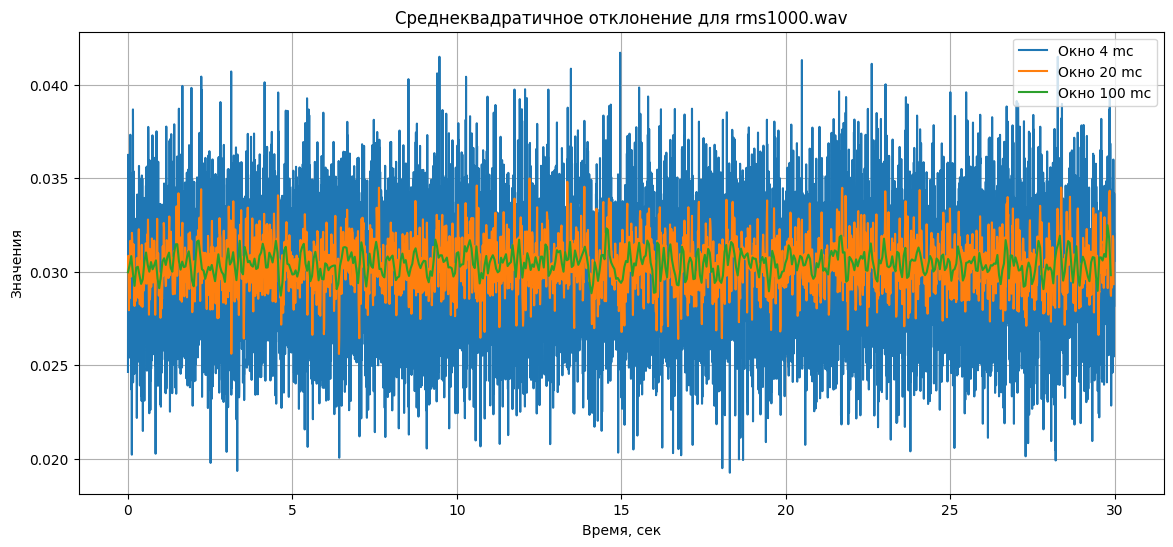

In [ ]:
# Вычисляем среднеквадратичное отклонение (с окном 4 мс, перекрытие 50%) и строим график
block_size = round(sr_rms1000 / 250)
hop_size = round(block_size / 2)

rms1000_rms_4 = rms(data_rms1000, block_size, hop_size)
frames4 = range(len(rms1000_rms_4))
t4 = librosa.frames_to_time(frames4, hop_length=hop_size, sr=sr_rms1000)

# Вычисляем среднеквадратичное отклонение (с окном 20 мс, перекрытие 50%) и строим график
block_size = round(sr_rms1000 / 50)
hop_size = round(block_size / 2)

rms1000_rms_20 = rms(data_rms1000, block_size, hop_size)
frames20 = range(len(rms1000_rms_20))
t20 = librosa.frames_to_time(frames20, hop_length=hop_size, sr=sr_rms1000)

# Вычисляем среднеквадратичное отклонение (с окном 100 мс, перекрытие 50%) и строим график
block_size = round(sr_rms1000 / 10)
hop_size = round(block_size / 2)

rms1000_rms_100 = rms(data_rms1000, block_size, hop_size)
frames100 = range(len(rms1000_rms_100))
t100 = librosa.frames_to_time(frames100, hop_length=hop_size, sr=sr_rms1000)

# Графики среднеквадратичного отклонения
plt.figure(figsize=(14, 6))
plt.title("Среднеквадратичное отклонение для rms1000.wav")
plt.grid(True)
plt.xlabel("Время, сек")
plt.ylabel("Значения")
plt.plot(t4, rms1000_rms_4, label="Окно 4 mc")
plt.plot(t20, rms1000_rms_20, label="Окно 20 mc")
plt.plot(t100, rms1000_rms_100, label="Окно 100 mc")
plt.legend(loc=1)
plt.show()

<div class="alert alert-block alert-success">
<b>Ответ на задание 5:</b>
<a id="answer-job5"></a>

Больше окно - больше чисел попадает для вычисления СКО - более гладким будет график. Поскольку белый шум - случайный сигнал, где могут встречаться выбросы, при маленьком окне значения СКО скачут сильнее.
</div>